# Network Comparison: `small` vs `small_parthenope`

This notebook compares the primordial abundances and time evolution predicted by the `small` network and the `small_parthenope` network.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the repo root is in path
sys.path.append(os.getcwd())

from primat.backend import run_bbn
from primat.evolution import Y_interpolator, T_gamma_interpolator
from primat.constants import CONST

# Uses primat.backend.run_bbn() only (works on either backend); the curve data
# below comes from primat.evolution's backend-agnostic interpolators built on
# each run's EvolutionResult (output_time_evolution=True).

# Configuration
params = {
    "output_time_evolution": True,
    "output_file": None,
    "verbose": False
}

# Solve for both networks
print("Solving small network...")
res_small = run_bbn({**params, "network": "small"})

print("Solving small_parthenope network...")
res_parthenope = run_bbn({**params, "network": "small_parthenope"})

print("Done.")


Solving small network...
Solving small_parthenope network...
Done.


[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.  done.


In [2]:
# Compare final abundances using Y_final
nuclides = [n for n in res_small['Y_final'] if n in res_parthenope['Y_final']]
data = {
    "small": [res_small['Y_final'][n] for n in nuclides],
    "small_parthenope": [res_parthenope['Y_final'][n] for n in nuclides],
}
df = pd.DataFrame(data, index=nuclides)
df["rel_diff"] = (df["small_parthenope"] - df["small"]) / df["small"]

print("Comparison of final abundances:")
print(df)


Comparison of final abundances:
            small  small_parthenope  rel_diff
n    3.995337e-16      2.726674e-16 -0.317536
p    7.529344e-01      7.530416e-01  0.000142
H2   1.833434e-05      1.881940e-05  0.026457
H3   5.849843e-08      6.043513e-08  0.033107
He3  7.770588e-06      7.730628e-06 -0.005142
He4  6.175136e-02      6.172434e-02 -0.000438
Li7  2.180889e-11      2.075526e-11 -0.048312
Be7  3.968373e-10      3.417927e-10 -0.138708


/var/folders/x_/t8nzcr8d7_91h7fdrxdr8b180000gp/T/ipykernel_11294/1532134381.py:21: RuntimeWarning: invalid value encountered in divide
  rel_diff = (Y_p_interp - Y_s) / Y_s


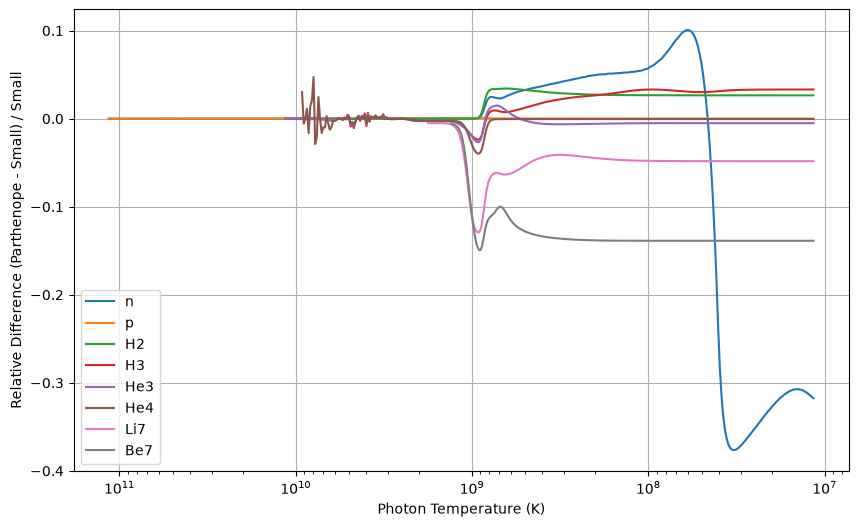

In [3]:
# Plot relative difference of nuclide time evolution
plt.figure(figsize=(10, 6))

ev_small = res_small['evolution']
ev_parthenope = res_parthenope['evolution']

# Use each run's own time grid and the backend-agnostic T_gamma interpolator.
t_small = ev_small.t
t_parthenope = ev_parthenope.t
# T_gamma_interpolator returns MeV; convert to Kelvin for the x-axis label.

T_small = T_gamma_interpolator(ev_small)(t_small) * CONST.MeV_to_Kelvin
T_parthenope = T_gamma_interpolator(ev_parthenope)(t_parthenope) * CONST.MeV_to_Kelvin

for n in nuclides:
    Y_s = Y_interpolator(ev_small, n)(t_small)
    Y_p = Y_interpolator(ev_parthenope, n)(t_parthenope)

    # Interpolate parthenope evolution onto small grid (T decreases with time)
    Y_p_interp = np.interp(T_small, T_parthenope[::-1], Y_p[::-1])
    rel_diff = (Y_p_interp - Y_s) / Y_s

    mask = Y_s > 1e-25
    plt.plot(T_small[mask], rel_diff[mask], label=n)

plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("Photon Temperature (K)")
plt.ylabel("Relative Difference (Parthenope - Small) / Small")
plt.legend()
plt.grid(True)
plt.show()